# Implement GMM without any builtin functions

In [88]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
#cleaned and load the dataset
df = pd.read_csv('dataset/GMM-Faithful-Geyser-Dataset/faithful.csv', header=0)
X = df.iloc[:, -2:]

X.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


### 1. Parse and plot all data points on 2-D plane.

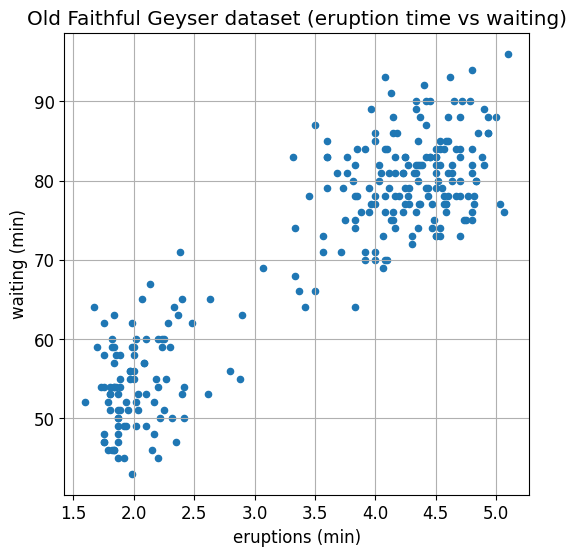

In [90]:
# scatter plot of data
plt.figure(figsize=(6,6))
plt.scatter(X['eruptions'], X['waiting'], s=20)
plt.xlabel('eruptions (min)')
plt.ylabel('waiting (min)')
plt.title('Old Faithful Geyser dataset (eruption time vs waiting)')
plt.grid(True)
plt.show()

### 2. A bimodal GMM model to fit all data points using EM algorithm
<span>For this problem, we assume the covariance matrix is spherical (i.e., it has the form of σ2I for scalar σ) and you can randomly initialize Gaussian parameters<span>
<li>Plot the trajectories of two mean vectors in 2 dimensions (i.e., coordinates vs. iteration).
<li>Run your program for 50 times with different initial parameter guesses. Show the distribution of the total number of iterations needed for algorithm to converge.

In [91]:
# df to numpy array
X = X.values 
n,d = X.shape
K=2 # bimodal

def mvnSpherical(x, mu, sig2):
    diff = x - mu
    sqNorm = np.sum(diff**2, axis=1)
    den = (2 * np.pi * sig2)**(d/2)
    return np.exp(-0.5 * sqNorm / sig2) / den

In [92]:
#EM algorithm
def gmm_em(X, K=2, tol=1e-6, maxIter=500,randState=None, trackHist=True):
    rng = np.random.RandomState(randState)
    n, d = X.shape
    
    #random init
    idx = rng.choice(n, size=K, replace=False)
    mus = X[idx].astype(float)
    pis = np.ones(K) / K
    sigs = np.ones(K) * np.var(X, axis=0).mean()
    
    if trackHist:
        musHist = [mus.copy()]
    
    loglikHist = []
    
    for it in range(maxIter):
        #E step
        probs = np.zeros((n,K))
        for k in range(K):
            probs[:,k] = pis[k] * mvnSpherical(X, mus[k][None,:].repeat(n, axis=0), sigs[k])
        r = probs / probs.sum(axis=1, keepdims=True)
        
        #log-likelihood
        loglik = np.sum(np.log(probs.sum(axis=1)))
        loglikHist.append(loglik)
        
        #M step 
        Nk = r.sum(axis=0)
        pis = Nk / n
        musNew = np.zeros_like(mus)
        sigsNew = np.zeros_like(sigs)
        for k in range(K):
            musNew[k] = (r[:,k][:,None] * X).sum(axis=0) / Nk[k]
            diffs = X - musNew[k]
            sigsNew[k] = (r[:,k] @ np.sum(diffs**2, axis=1)) / (d * Nk[k])
            sigsNew[k] = max(sigsNew[k], 1e-6)
        
        #termination based on log-likelihood improvement
        if it>0 and abs(loglikHist[-1]-loglikHist[-2]) < tol:
            mus = musNew
            sigs = sigsNew
            break
        
        mus = musNew
        sigs = sigsNew
        if trackHist:
            musHist.append(mus.copy())
    
    return mus, sigs, pis, musHist, it+1

Random init EM converged in 13 iterations
Means: [[ 4.29391102 80.26491597]
 [ 2.09767242 54.74285092]]


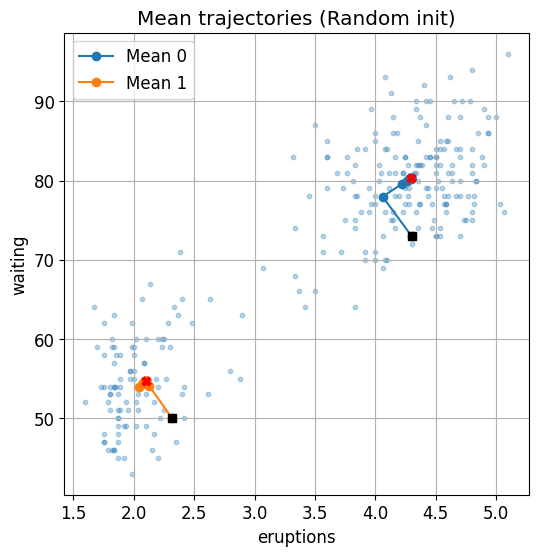

In [93]:
#run EM
mus, sigs, pis, musHist, nIter = gmm_em(X, randState=42)
print("Random init EM converged in", nIter, "iterations")
print("Means:", mus)

#plot mean trajectories
musArr = np.stack(musHist, axis=0)
plt.figure(figsize=(6,6))
for k in range(K):
    traj = musArr[:,k,:]
    plt.plot(traj[:,0], traj[:,1], marker='o', label=f'Mean {k}', zorder=3)
    plt.scatter(traj[0,0], traj[0,1], marker='s', color='black', s=40, zorder=4)  #start
    plt.scatter(traj[-1,0], traj[-1,1], marker='X', color='red', s=40, zorder=5)  #end
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.3)
plt.xlabel('eruptions')
plt.ylabel('waiting')
plt.title('Mean trajectories (Random init)')
plt.legend()
plt.grid(True)
plt.show()

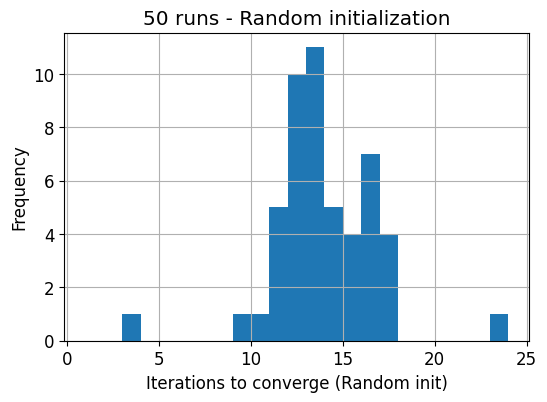

In [94]:
# run 50 trials to get iteration distribution
iterationsList = []
for seed in range(50):
    _, _, _, _, iters = gmm_em(X, randState=seed)
    iterationsList.append(iters)

plt.figure(figsize=(6,4))
plt.hist(iterationsList, bins=range(1, max(iterationsList)+2))
plt.xlabel('Iterations to converge (Random init)')
plt.ylabel('Frequency')
plt.title('50 runs - Random initialization')
plt.grid(True)
plt.show()

#### Termination Criteria for EM Algorithm
In our Gaussian Mixture Model (GMM) implementation, the EM algorithm is terminated when the change in log-likelihood between consecutive iterations is smaller than a small threshold (here,1e-6):
<span>
**Reasoning:**
1. **Monotonic Increase:** EM guarantees that the log-likelihood is non-decreasing with each iteration.  
2. **Convergence Detection:** When the improvement becomes negligibly small, the parameters have effectively converged, and further iterations produce little to no benefit.  
3. **Numerical Stability:** Monitoring log-likelihood is more robust than checking parameter changes, especially for small variances.  
4. **Safety Net:** A maximum number of iterations (here,500) is also imposed to prevent infinite loops in rare cases.
<span>

### 3. Repeat the task in (2) but with the initial guesses of the parameters generated from the following process:
<li>Run a k-means algorithm over all the data points with K = 2 and label each point with one of the two clusters.
<li>Estimate the first guess of the mean and covariance matrices using maximum likelihood over the labeled data points. Compare the algorithm performances of (2) and (3).

In [95]:
#K-means
def kmeans(X, K=2, maxIter=100, tol=1e-4, randState=None):
    rng = np.random.RandomState(randState)
    n, d = X.shape
    idx = rng.choice(n, K, replace=False)
    centroids = X[idx].astype(float)
    for _ in range(maxIter):
        dists = np.linalg.norm(X[:,None,:] - centroids[None,:,:], axis=2)
        labels = np.argmin(dists, axis=1)
        newCentroids = np.array([X[labels==k].mean(axis=0) if np.any(labels==k) else centroids[k] for k in range(K)])
        if np.linalg.norm(newCentroids-centroids) < tol:
            break
        centroids = newCentroids
    return centroids, labels

In [96]:
#EM with k-means
def gmm_em_kmeans(X, K=2, tol=1e-6, maxIter=500, randState=None, trackHist=True):
    centroids, labels = kmeans(X, K=K, randState=randState)
    mus = centroids.copy()
    pis = np.array([np.mean(labels==k) for k in range(K)])
    sigs = np.zeros(K)
    n, d = X.shape
    for k in range(K):
        members = X[labels==k]
        sigs[k] = np.sum(np.sum((members-mus[k])**2, axis=1)) / (d*len(members))
    if trackHist:
        musHist = [mus.copy()]
    
    loglikHist = []
    for it in range(maxIter):
        probs = np.zeros((n,K))
        for k in range(K):
            probs[:,k] = pis[k] * mvnSpherical(X, mus[k][None,:].repeat(n, axis=0), sigs[k])
        r = probs / probs.sum(axis=1, keepdims=True)
        loglik = np.sum(np.log(probs.sum(axis=1)))
        loglikHist.append(loglik)
        
        Nk = r.sum(axis=0)
        pis = Nk / n
        musNew = np.zeros_like(mus)
        sigsNew = np.zeros_like(sigs)
        for k in range(K):
            musNew[k] = (r[:,k][:,None]*X).sum(axis=0)/Nk[k]
            diffs = X - musNew[k]
            sigsNew[k] = (r[:,k] @ np.sum(diffs**2, axis=1)) / (d*Nk[k])
            sigsNew[k] = max(sigsNew[k], 1e-6)
        if it>0 and abs(loglikHist[-1]-loglikHist[-2])<tol:
            mus = musNew
            sigs = sigsNew
            break
        mus = musNew
        sigs = sigsNew
        if trackHist:
            musHist.append(mus.copy())
    
    return mus, sigs, pis, musHist, it+1

In [97]:
#run EM with k-means init
musKM, sigsKM, pisKM, musHistKM, nIterKM = gmm_em_kmeans(X, randState=42)
print("K-means init EM converged in", nIterKM, "iterations")
print("Means:", musKM)

K-means init EM converged in 6 iterations
Means: [[ 4.29391647 80.26497355]
 [ 2.09767997 54.74294856]]


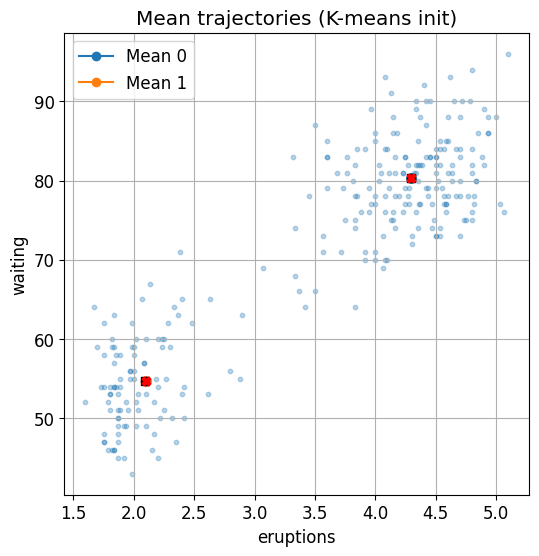

In [98]:
#plot mean trajectories
musArrKM = np.stack(musHistKM, axis=0)
plt.figure(figsize=(6,6))
for k in range(K):
    traj = musArrKM[:,k,:]
    plt.plot(traj[:,0], traj[:,1], marker='o', label=f'Mean {k}', zorder=3)
    plt.scatter(traj[0,0], traj[0,1], marker='s', color='black', s=40, zorder=4)  #start
    plt.scatter(traj[-1,0], traj[-1,1], marker='X', color='red', s=40, zorder=5)  #end
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.3)
plt.xlabel('eruptions')
plt.ylabel('waiting')
plt.title('Mean trajectories (K-means init)')
plt.legend()
plt.grid(True)
plt.show()


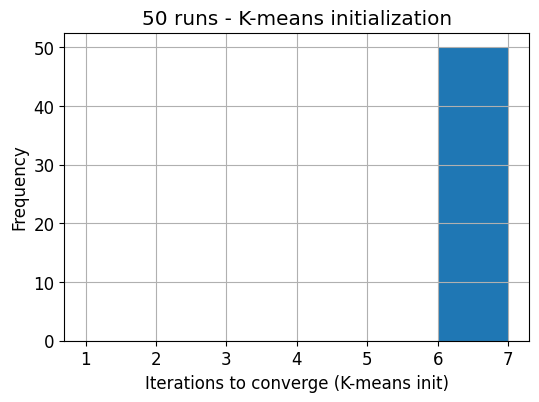

In [99]:
#run 50 trials to get iteration distribution
iterationsListKM = []
for seed in range(50):
    _, _, _, _, iters = gmm_em_kmeans(X, randState=seed)
    iterationsListKM.append(iters)

plt.figure(figsize=(6,4))
plt.hist(iterationsListKM, bins=range(1, max(iterationsListKM)+2))
plt.xlabel('Iterations to converge (K-means init)')
plt.ylabel('Frequency')
plt.title('50 runs - K-means initialization')
plt.grid(True)
plt.show()

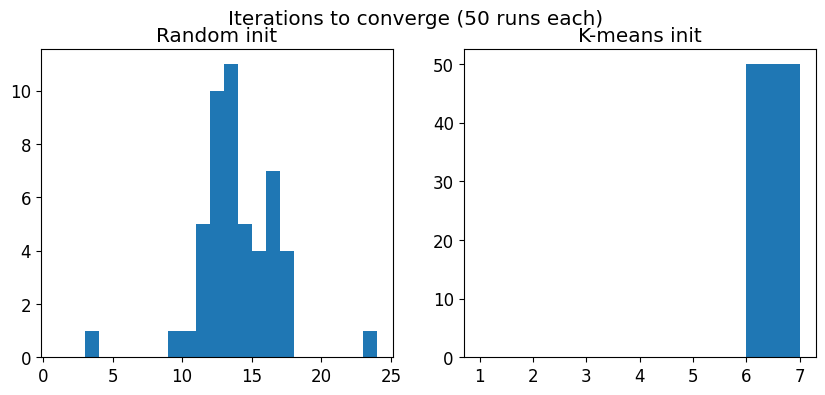

  Init Method  Mean Iterations  Median Iterations  Min Iterations  \
0      Random            13.46               13.0               3   
1     K-means             6.00                6.0               6   

   Max Iterations  
0              23  
1               6  


In [100]:
#compare random vs k-means init
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(iterationsList, bins=range(1, max(iterationsList)+2))
plt.title('Random init')
plt.subplot(1,2,2)
plt.hist(iterationsListKM, bins=range(1, max(iterationsListKM)+2))
plt.title('K-means init')
plt.suptitle('Iterations to converge (50 runs each)')
plt.show()

#statistics
itersRand = np.array(iterationsList)
itersKM = np.array(iterationsListKM)

summary = {
    'Init Method': ['Random', 'K-means'],
    'Mean Iterations': [itersRand.mean(), itersKM.mean()],
    'Median Iterations': [np.median(itersRand), np.median(itersKM)],
    'Min Iterations': [itersRand.min(), itersKM.min()],
    'Max Iterations': [itersRand.max(), itersKM.max()],
}
sumUp = pd.DataFrame(summary)
print(sumUp)